SHAP values shape: (35369, 21)


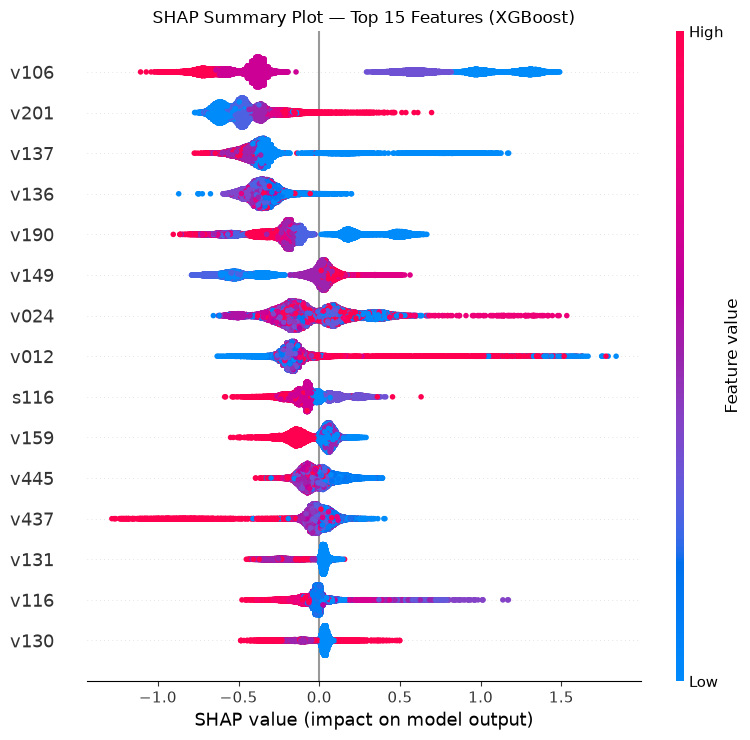

✅ SHAP summary plot saved.


In [1]:
import pandas as pd
import numpy as np
import pickle
import os
import matplotlib.pyplot as plt
import shap

with open('C:/maternal_health_project/models/train_test_data.pkl','rb') as f:
    d = pickle.load(f)
X_test, y_test = d['X_test'], d['y_test']
feature_cols    = d['feature_cols']
encoders        = d['encoders']

# Use XGBoost — justified by the NNLS weights (Phase 4), which assigned it the
# highest weight (0.621) among all base models, confirming it carries the most signal.
with open('C:/maternal_health_project/models/xgb_model.pkl','rb') as f:
    best_pkg = pickle.load(f)
best_model = best_pkg['model']

os.makedirs('C:/maternal_health_project/figures/shap_plots', exist_ok=True)

explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test)

if isinstance(shap_values, list):
    sv = shap_values[1]
elif shap_values.ndim == 3:
    sv = shap_values[:, :, 1]
else:
    sv = shap_values

print("SHAP values shape:", sv.shape)

plt.figure(figsize=(10,8))
shap.summary_plot(sv, X_test, feature_names=list(X_test.columns), max_display=15, show=False)
plt.title("SHAP Summary Plot — Top 15 Features (XGBoost)")
plt.tight_layout()
plt.savefig('C:/maternal_health_project/figures/shap_plots/shap_summary.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ SHAP summary plot saved.")

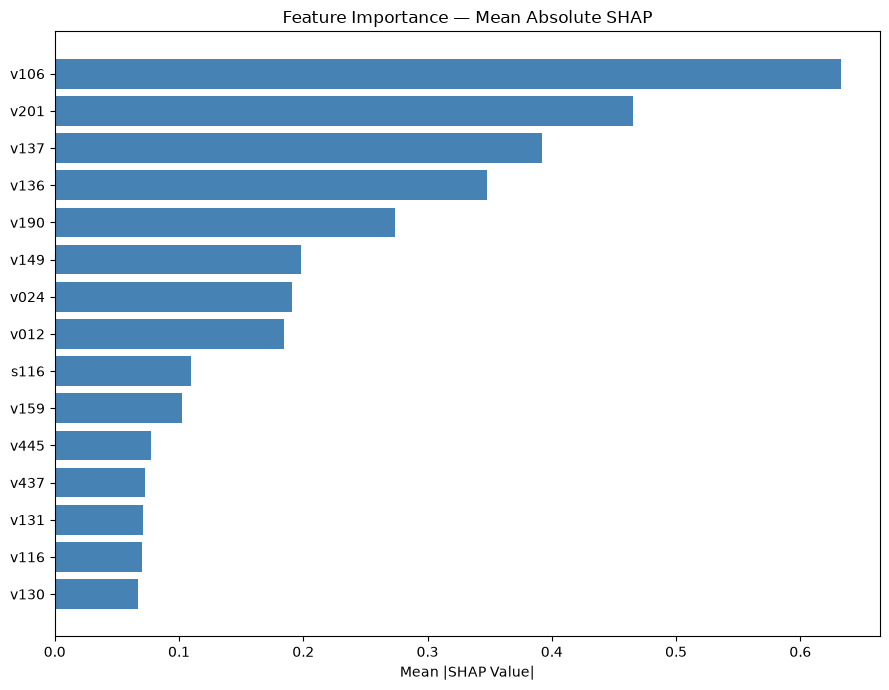

Bihar: skipped (only 0 test rows)
Rajasthan: skipped (only 0 test rows)
Odisha: skipped (only 0 test rows)
Uttar Pradesh: skipped (only 0 test rows)
Assam: skipped (only 0 test rows)
✅ State SHAP analysis saved.


In [2]:
import json

mean_shap = np.abs(sv).mean(axis=0)
shap_df = pd.DataFrame({'feature': X_test.columns, 'shap': mean_shap})
shap_df = shap_df.sort_values('shap', ascending=True).tail(15)

plt.figure(figsize=(9,7))
plt.barh(shap_df['feature'], shap_df['shap'], color='steelblue')
plt.xlabel('Mean |SHAP Value|')
plt.title('Feature Importance — Mean Absolute SHAP')
plt.tight_layout()
plt.savefig('C:/maternal_health_project/figures/shap_plots/shap_bar.png', dpi=300)
plt.show()

# Recover ORIGINAL state codes via the saved encoder — X_test['v024'] is label-encoded
if 'v024' in encoders:
    raw_state = encoders['v024'].inverse_transform(X_test['v024'].astype(int))
else:
    raw_state = X_test['v024']

# VERIFY these codes against your NFHS-5 codebook (v024 value labels) before trusting them
target_states = {10:'Bihar', 8:'Rajasthan', 21:'Odisha', 9:'Uttar Pradesh', 18:'Assam'}

X_test_s = X_test.copy()
X_test_s['state'] = raw_state

state_results = {}
for code, name in target_states.items():
    mask = (X_test_s['state'] == code).values
    if mask.sum() < 50:
        print(f"{name}: skipped (only {mask.sum()} test rows)")
        continue
    sv_state = sv[mask]
    top3_idx = np.abs(sv_state).mean(axis=0).argsort()[-3:][::-1]
    state_results[name] = [
        (list(X_test.columns)[i], round(float(np.abs(sv_state).mean(axis=0)[i]), 4))
        for i in top3_idx
    ]
    print(f"{name}: {state_results[name]}")

os.makedirs('C:/maternal_health_project/outputs', exist_ok=True)
with open('C:/maternal_health_project/outputs/state_shap.json','w') as f:
    json.dump(state_results, f, indent=2)
print("✅ State SHAP analysis saved.")